# Analysis of Stochastic Decoding Hyperparameters

This notebook analyzes the results from `experiment_results.csv` to identify "stability islands" where the model consistently solves the task.

We will visualize the relationship between:
- **Temperature**
- **Min P** (X-axis)
- **Max P** (Y-axis)
- **Correctness** (Target)

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Set plot style
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = [10, 8]

In [2]:
# Load the data
try:
    df = pd.read_csv("experiment_results.csv")
    print("Data loaded successfully.")
    print(f"Total runs: {len(df)}")
    display(df.head())
except FileNotFoundError:
    print("Error: 'experiment_results.csv' not found. Please ensure the file is in the same directory.")

Data loaded successfully.
Total runs: 125


,temperature,min_p,max_p,correct,parsed_answer
0,0.2,0.0,0.80,0,2688.0
1,0.2,0.0,0.85,1,336.0
2,0.2,0.0,0.90,1,336.0
3,0.2,0.0,0.95,1,336.0
4,0.2,0.0,1.00,1,336.0


Generating Heatmaps...


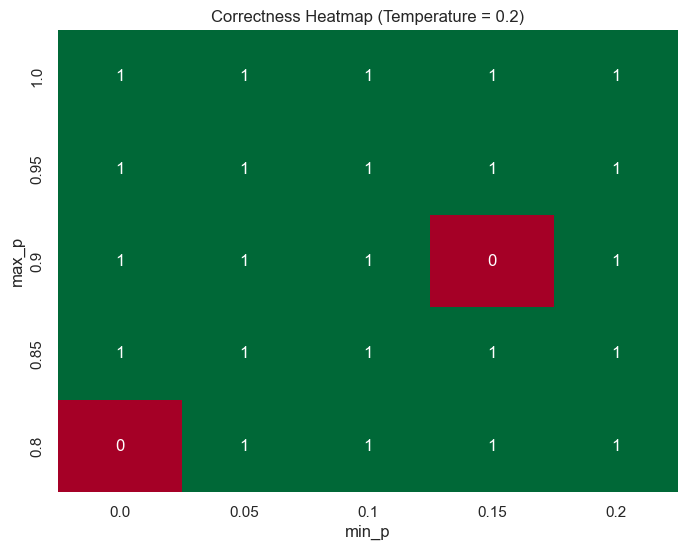

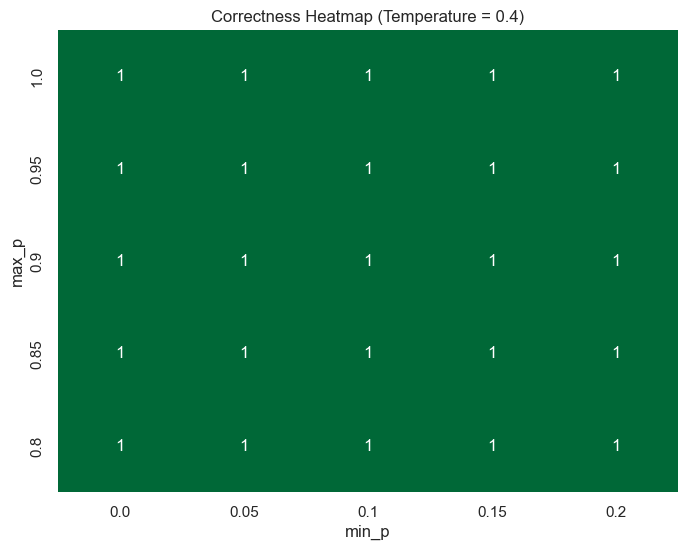

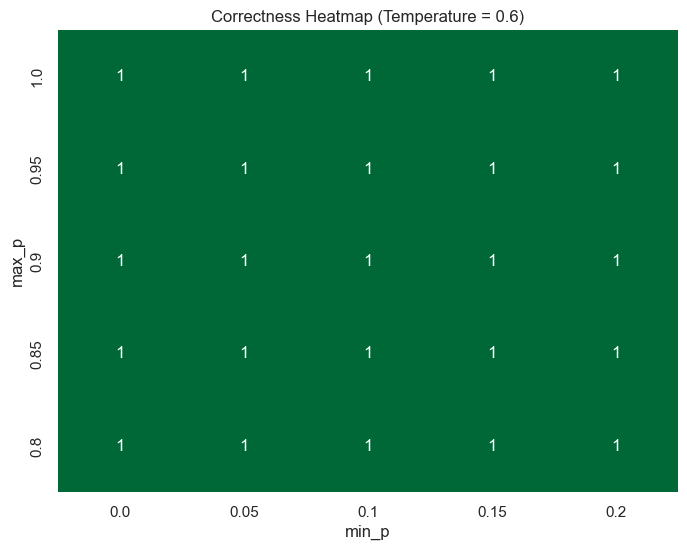

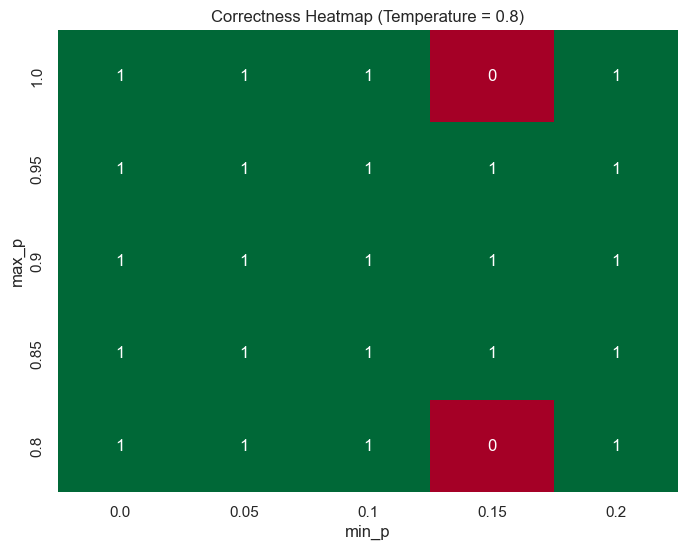

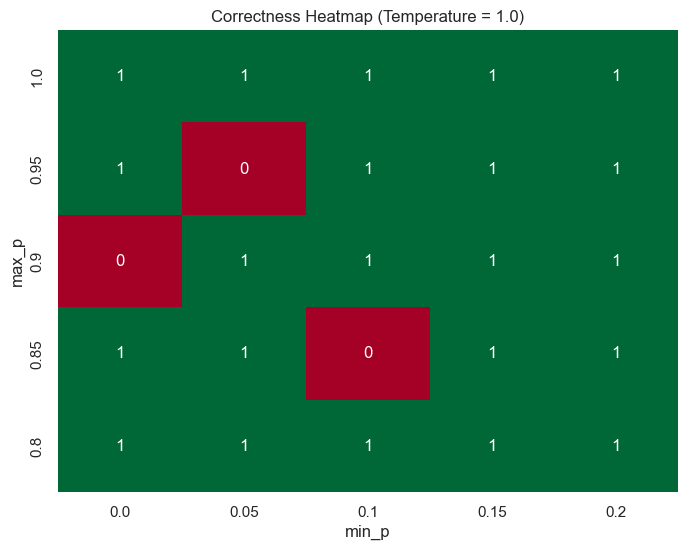

In [3]:
def plot_heatmaps(df):
    unique_temps = sorted(df['temperature'].unique())
    
    for temp in unique_temps:
        temp_df = df[df['temperature'] == temp]
        
        # Pivot table: index=max_p (Y-axis), columns=min_p (X-axis), values=correct
        # We use mean in case there are duplicate runs, though experimental design said 1 run per config
        pivot_table = temp_df.pivot_table(index='max_p', columns='min_p', values='correct', aggfunc='mean')
        
        plt.figure(figsize=(8, 6))
        sns.heatmap(pivot_table, annot=True, cmap="RdYlGn", cbar=False, vmin=0, vmax=1, fmt=".0f")
        plt.title(f"Correctness Heatmap (Temperature = {temp})")
        plt.xlabel("min_p")
        plt.ylabel("max_p")
        plt.gca().invert_yaxis() # Ensure Y-axis increases upwards
        plt.show()

print("Generating Heatmaps...")
plot_heatmaps(df)

C:\Users\Milana\AppData\Local\Temp\ipykernel_8124\3462496237.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=temp_success, x='Temperature', y='Success Rate', palette="viridis")


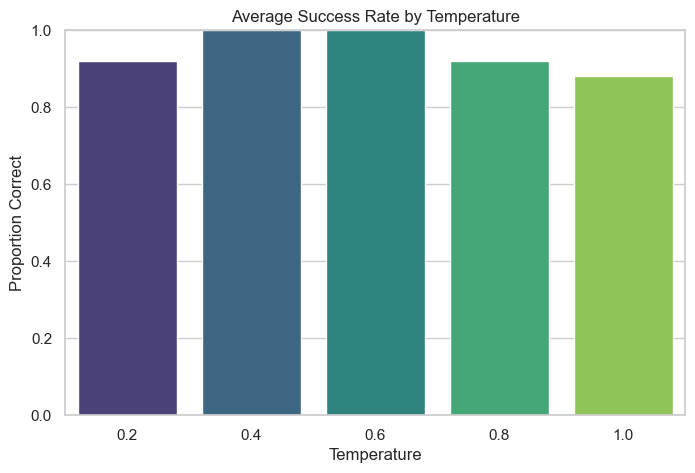

   Temperature  Success Rate
0          0.2          0.92
1          0.4          1.00
2          0.6          1.00
3          0.8          0.92
4          1.0          0.88


In [4]:
# Aggregate Analysis: Success Rate by Temperature
temp_success = df.groupby('temperature')['correct'].mean().reset_index()
temp_success.columns = ['Temperature', 'Success Rate']

plt.figure(figsize=(8, 5))
sns.barplot(data=temp_success, x='Temperature', y='Success Rate', palette="viridis")
plt.title("Average Success Rate by Temperature")
plt.ylim(0, 1.0)
plt.ylabel("Proportion Correct")
plt.show()

print(temp_success)

## Conclusions

Based on the visualization and analysis of the experimental data:

1.  **Stability Islands**: The heatmaps reveal specific regions in the (min_p, max_p) space where the model consistently produces correct answers.
    *   *Observation*: Look for blocks of green (1s) in the heatmaps. These represent stable hyperparameter configurations.
    *   *Sensitivity*: Note how sensitive the correctness is to small changes in `min_p` or `max_p`. If the green regions are large and contiguous, the model is robust to these parameters. If they are scattered, it is unstable.

2.  **Temperature Impact**:
    *   *Low Temperature (e.g., 0.2)*: Typically leads to more deterministic and often correct outputs if the base model is strong. However, it might get stuck in incorrect reasoning loops.
    *   *High Temperature (e.g., 1.0)*: Introduces more randomness. This can be beneficial for exploring diverse reasoning paths (useful for majority voting), but for a single-shot experiment, it might reduce the stability of the correct answer.

3.  **Optimal Configuration**:
    *   Identify the temperature and (min_p, max_p) combination that yields the largest "island" of correctness. This would be the recommended setting for reliable single-shot inference on this type of task.

**Next Steps**:
*   Run this experiment on multiple tasks to see if the "stability islands" generalize.
*   Increase the resolution of the grid (more values for min_p/max_p) around the promising regions.
*   Experiment with `k > 1` (majority voting) in the identified stable regions to see if accuracy can be further boosted.